In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from cosmographi.utils.perturbations import generate_perturbations_vector
import jax.numpy as jnp 
from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.instrument.rubin import RubinObservatory
from scipy.optimize import minimize
import numpy as np
import cosmographi as cp
import jax
import matplotlib.pyplot as plt
from cosmographi.utils.constants import M_sun, c_nm
from cosmographi.utils.flux import convert_to_jy, observer_to_rest_time
# jax.config.update("jax_enable_x64", True)
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import pandas as pd
from tinygp import GaussianProcess, kernels
from cosmographi.utils.perturbations import generate_perturbations_vector
from caskade import forward
from sklearn.neighbors import KNeighborsRegressor
from cosmographi.cosmology import Cosmology

# TODO: try clipping
# TODO: try exponentiating after interpolation for perturbations
# don't worry about mean of perturbations, instead control fluctuations
# include a flux_scale parameter -> control mean
# check lightcurvelynx


In [2]:
# class AGNSourceLipunova20182(AGNSourceLipunova2018):
#     @forward
#     def luminosity_density(self, w: jnp.ndarray, t: jnp.ndarray, integration_points: int = 100, perturbations=None) -> jnp.ndarray:
#         """ Interpolate the luminosity density ( erg/s/nm ) for a all combinations of the elements in <w> and <t>."""
#         t = jnp.atleast_1d(t)
#         base_luminosity = self.base_luminosity_density(w=w, num_integration_points=integration_points)
#         perturbation = jnp.interp(t, self.times, perturbations) # linearly interpolate perturbations
#         return base_luminosity[None, :] * perturbation[:, None]


class AGNSourceNearestNeighbours(AGNSourceLipunova2018):
    def __init__(self, cosmology: Cosmology = None, name: str = None, blackhole_mass: float = None, accretion_rate: float = None, inclination_angle: float = None, 
                     rin_to_rng: float = None, perturbations_ar: jnp.ndarray = None, start_time: float = None, end_time: float = None, **kwargs) -> None:
            super().__init__(
            cosmology=cosmology,
            name=name,
            blackhole_mass=blackhole_mass,
            accretion_rate=accretion_rate,
            inclination_angle=inclination_angle,
            rin_to_rng=rin_to_rng,
            perturbations_ar=perturbations_ar,
            start_time=start_time,
            end_time=end_time,
            **kwargs,
        )

    @forward
    def luminosity_density(self, w: jnp.ndarray, t: jnp.ndarray, integration_points: int = 100, perturbations=None) -> jnp.ndarray:
        """ Interpolate the luminosity density ( erg/s/nm ) for a all combinations of the elements in <w> and <t>."""
        t = jnp.atleast_1d(t)
        base_luminosity = self.base_luminosity_density(w=w, num_integration_points=integration_points)
        def interp(t, k):
            distances = jnp.abs(self.times - t)
            idx = jnp.argsort(distances)[:k]
            return jnp.mean(perturbations[idx])
        perturbation = jnp.atleast_1d(interp(t, 1))
        return base_luminosity[None, :] * perturbation[:, None]

In [3]:
# def generate_perturbations_vector(alpha, n_samples, sample_rate=1.0, seed: int | None = None):
#     """
#     Generates 1D colored noise and plots the transformation steps.

#     Parameters:
#     alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
#     n_samples (int): Number of data points to generate.
#     sample_rate (float): Assumed sample rate for frequency calculation.
#     """
#     rng = np.random.default_rng(seed=seed)
#     white_noise = rng.normal(0, 1, n_samples)
#     fft_white = jnp.fft.rfft(white_noise)
#     frequencies = jnp.fft.rfftfreq(n_samples, d=1/sample_rate)
#     # Ignore divide by zero for the DC component (f=0)
#     with np.errstate(divide='ignore', invalid='ignore'):
#         # Amplitude scales as 1/f^(alpha/2)
#         scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))
#     scaling_factor = scaling_factor.at[0].set(0.0)
#     fft_colored = fft_white * scaling_factor
#     colored_noise = jnp.fft.irfft(fft_colored, n=n_samples)
#     exp = jnp.exp(colored_noise)
#     return exp / jnp.mean(exp)

def generate_perturbations_gp(scale: float, noise: float, num_samples: int, key = None) -> jnp.ndarray:
    x = jnp.arange(num_samples)
    kernel = kernels.stationary.Exp(scale=scale)
    gp = GaussianProcess(kernel, x, diag=noise**2)
    samples = gp.sample(key)
    return jnp.exp(samples) 
    # return jnp.exp(samples) / jnp.mean(jnp.exp(samples))

In [4]:
# def generate_perturbations_vector(alpha, n_samples, sample_rate=1.0, seed: int | None = None):
#     """
#     Generates 1D colored noise and plots the transformation steps.

#     Parameters:
#     alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
#     n_samples (int): Number of data points to generate.
#     sample_rate (float): Assumed sample rate for frequency calculation.
#     """
#     rng = np.random.default_rng(seed=seed)
#     white_noise = rng.normal(0, 1, n_samples)
#     fft_white = jnp.fft.rfft(white_noise)
#     frequencies = jnp.fft.rfftfreq(n_samples, d=1/sample_rate)
#     # Ignore divide by zero for the DC component (f=0)
#     with np.errstate(divide='ignore', invalid='ignore'):
#         # Amplitude scales as 1/f^(alpha/2)
#         scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))
#     scaling_factor = scaling_factor.at[0].set(0.0)
#     fft_colored = fft_white * scaling_factor
#     colored_noise = jnp.fft.irfft(fft_colored, n=n_samples)
#     exp = jnp.exp(colored_noise)
#     return exp 

# def generate_perturbations_gp(scale: float, noise: float, num_samples: int, key = None) -> jnp.ndarray:
#     x = jnp.arange(num_samples)
#     kernel = kernels.stationary.Exp(scale=scale)
#     gp = GaussianProcess(kernel, x, diag=noise**2)
#     samples = gp.sample(key)
#     return jnp.exp(samples) 

In [5]:

def compute_neg_log_likelihood(x: tuple[float], observed_flux: jnp.ndarray, times: jnp.ndarray, 
                           band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, 
                           blackhole_mass: float, accretion_rate: float, inclination_angle: float, rin_to_rng: float, z: float, noise_var = None) -> float: 
    """ Must pass with same format as Instrument.observe
    """
    start_time = observer_to_rest_time(t_obs = times[0], z=z)
    end_time = observer_to_rest_time(t_obs = times[-1], z=z)
    num_perturbation_samples = 1000
    proposed_alpha  = x
    sample_rate = num_perturbation_samples / (end_time - start_time)
    perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, sample_rate=sample_rate, seed=42)
    agn = AGNSourceLipunova2018(blackhole_mass=blackhole_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=rin_to_rng, inclination_angle=inclination_angle)
    rubin = RubinObservatory()
    rubin.throughput.trim()
    rubin.throughput.to_dynamic() 
    band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, band, return_dict=True)
    key = jax.random.key(42)
    agn.z = z
    agn.t0 = start_time
    C = cp.cosmology.Cosmology()
    agn.cosmology = C
    agn.mu = agn.cosmology.distance_modulus(z)
    source_values = jnp.asarray(agn.get_values())
    survey_values = jnp.asarray(rubin.get_values())    
    obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
    model_flux = obs(key, band, exp_time, sky_brightness, PSF_Aeff, agn, times, source_values, survey_values)[2]  
    def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict
    band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
    band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
    zero_points = jnp.array([band_id_to_zero[i]for i in range(len(band_id_to_zero))])
    model_flux_jansky = convert_to_jy(model_flux, band, zero_points, rubin.effective_aperture)
    model_flux_comparable_units = model_flux_jansky * 1e9
    n = len(observed_flux)
    ll = (- n/2 * jnp.log(2*jnp.pi) - n/2 * jnp.log(noise_var) - 1/2/noise_var * jnp.sum((model_flux_comparable_units - observed_flux) ** 2)) * (-1)
    return float(ll)


def minimize_log_likelihood(observed_flux: jnp.ndarray, times: jnp.ndarray, band: jnp.ndarray, exp_time: jnp.ndarray, 
                            sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, blackhole_mass: float, accretion_rate: float, 
                            inclination_angle: float, z: float, noise_var: float | None = None, rin_to_rng: float = 6) -> float:
    bounds = [(0.0, 2.0)]
    args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z, noise_var)
    x0 = np.asarray([0.88])
    results = minimize(compute_neg_log_likelihood, x0, args, method="Powell", bounds=bounds)
    return results

In [6]:
# def compute_neg_log_likelihood_gp(x: tuple[float], observed_flux: jnp.ndarray, times: jnp.ndarray, 
#                            band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, 
#                            blackhole_mass: float, accretion_rate: float, inclination_angle: float, rin_to_rng: float, z: float, noise_var = None) -> float: 
#     """ Must pass with same format as Instrument.observe
#     """
#     start_time, end_time = (times[0], times[-1])
#     scale, noise = x
#     key = jax.random.key(1)
#     num_perturbation_samples = 1000
#     perturbations = generate_perturbations_gp(scale=scale, noise=noise, num_samples=num_perturbation_samples, key=key)
#     agn = AGNSourceLipunova2018(blackhole_mass=blackhole_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
#                                 start_time=start_time, end_time=end_time, rin_to_rng=rin_to_rng, inclination_angle=inclination_angle)
#     rubin = RubinObservatory()
#     rubin.throughput.trim()
#     rubin.throughput.to_dynamic() 
#     band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, band, return_dict=True)
#     agn.t0 = start_time
#     C = cp.cosmology.Cosmology()
#     agn.z = z
#     agn.cosmology = C
#     agn.mu = agn.cosmology.distance_modulus(z)
#     source_values = jnp.asarray(agn.get_values())
#     survey_values = jnp.asarray(rubin.get_values())    
#     obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
#     model_flux = obs(key, band, exp_time, sky_brightness, PSF_Aeff, agn, times, source_values, survey_values)[2]  
#     def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
#         dict = {}
#         for key in idx_to_bandstr:
#             dict[key] = band_str_to_zero[idx_to_bandstr[key]]
#         return dict
#     band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
#     band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
#     zero_points = jnp.array([band_id_to_zero[i]for i in range(len(band_id_to_zero))])
#     model_flux_jansky = convert_to_jy(model_flux, band, zero_points, rubin.effective_aperture)
#     model_flux_comparable_units = model_flux_jansky * 1e9
#     n = len(observed_flux)
#     ll = (- n/2 * jnp.log(2*jnp.pi) - n/2 * jnp.log(noise_var) - 1/2/noise_var * jnp.sum((model_flux_comparable_units - observed_flux) ** 2)) * (-1)
#     return ll.item()


# def minimize_log_likelihood_gp(observed_flux: jnp.ndarray, times: jnp.ndarray, band: jnp.ndarray, exp_time: jnp.ndarray, 
#                             sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, blackhole_mass: float, accretion_rate: float, 
#                             inclination_angle: float, z: float, noise_var: float | None = None, rin_to_rng: float = 6) -> float:
#     args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z, noise_var)
#     bounds = [(1e-12, None), (1e-12, None)]
#     x0 = np.asarray([10, 0.1])
#     results = minimize(compute_neg_log_likelihood_gp, x0, args, method="Powell", bounds=bounds)
#     return results

In [7]:
# from the lightcurvlynx tutorial

passband_group = PassbandGroup.from_preset(preset="LSST")
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",)

# Draw redshift from the uniform distribution
redshift = NumpyRandomFunc("uniform", low=0.1, high=1.0)
# Draw decimal logarithm of the black hole mass (in solar masses)
# from the uniform distribution
lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)
# Transform to mass in solar masses
bh_mass = FunctionNode(
    lambda lg_mass: 10**lg_mass,
    lg_mass=lg_bh_mass,
    node_label="bh_mass",
)
# Eddington ratio for the accretion rate, e.g. accretion rate to critical value ratio
# First, we define a PDF function, for "blue" galaxies, see
# https://github.com/burke86/imbh_forecast/blob/master/var.ipynb
# https://ui.adsabs.harvard.edu/abs/2019ApJ...883..139S/abstract
# https://iopscience.iop.org/article/10.3847/1538-4357/aa803b/pdf
def edd_ratio_pdf(value):
    xi = 10**-1.65
    lambda_br = 10**-1.84
    delta1 = 0.471 - 0.7
    delta2 = 2.53
    min_lambda = 0.01
    max_lambda = 1.0
    value = np.asarray(value)
    fill_mask = (value >= min_lambda) & (value <= max_lambda)
    prob = np.zeros_like(value)
    prob[fill_mask] = xi / (
        (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
    )
    return prob

# We use a special random node to sample from this PDF
edd_ratio = SamplePDF(edd_ratio_pdf)
# We use a special distribution to draw positions from the survey coverage area
radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

model = AGN(
    # Reference time is not important for a stochastic model
    t0=obstable.time_bounds()[0],  # reference date, the survey start
    blackhole_mass=bh_mass,  # black hole mass in solar masses
    edd_ratio=edd_ratio,  # accretion rate to critical accretion rate raio
    redshift=redshift,
    ra=radec.ra,
    dec=radec.dec,
    cosmology=Planck18,
    inclination=0
)

# Make it reproducible
rng = np.random.default_rng(42)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

df = simulate_lightcurves(
    model=model,
    num_samples=1,
    survey_info=survey_info,
    param_cols=[
        "bh_mass.lg_mass",
        "AGN_0.edd_ratio",
    ],
    rng=rng,
)


Simulating: 100%|██████████| 1/1 [00:00<00:00,  1.83obj/s]


In [8]:
SECS_IN_YEAR = 31536000
data = jnp.asarray(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]])
lc = df.loc[0, "lightcurve"]
obs_idx = jnp.asarray(lc["obs_idx"])
obs_t = jnp.asarray(obstable["time"].iloc[obs_idx])
exp_times = jnp.asarray(obstable["exptime"].iloc[obs_idx])
sky_brightnesses = jnp.asarray(obstable["skybrightness"].iloc[obs_idx])
filters = obstable["filter"].iloc[obs_idx].to_numpy()
times = obs_t
flux = data[:, 1]
bh_mass = 10**df.loc[0,'bh_mass_lg_mass'] * M_sun
edd_ratio = df.loc[0, 'AGN_0_edd_ratio']
redshift = df.loc[0, 'z']
critical_accretion_rate = 1.4e18 * (bh_mass / M_sun)
accretion_rate = edd_ratio * SECS_IN_YEAR * critical_accretion_rate /1000
pixel_scale = obstable.survey_values["pixel_scale"]
PSF_Aeffs = (obstable["psf_footprint"].iloc[obs_idx].to_numpy()* pixel_scale**2)



In [9]:
results = minimize_log_likelihood(observed_flux=flux, band=filters, inclination_angle=0, 
                                  times=times, exp_time=exp_times, 
                                  sky_brightness=sky_brightnesses, 
                                  PSF_Aeff=PSF_Aeffs, blackhole_mass = bh_mass, 
                                  accretion_rate=accretion_rate, z=redshift, noise_var=jnp.var(flux))


# results_gp = minimize_log_likelihood_gp(observed_flux=flux, band=filters, inclination_angle=0, 
#                                   times=times, exp_time=exp_times, 
#                                   sky_brightness=sky_brightnesses, 
#                                   PSF_Aeff=PSF_Aeffs, blackhole_mass = bh_mass, 
#                                   accretion_rate=accretion_rate, z=redshift, noise_var=jnp.var(flux))

In [10]:
print(results)
# print(results_gp)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 380074656.74233145
       x: [ 1.772e-13]
     nit: 3
   direc: [[ 2.681e-09]]
    nfev: 222


In [11]:
proposed_alpha, num_perturbation_samples =  (results.x[0], 1000)
start_time = observer_to_rest_time(t_obs = times[0], z=redshift)
end_time = observer_to_rest_time(t_obs = times[-1], z=redshift)
sample_rate = num_perturbation_samples / (end_time - start_time)
perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, sample_rate=sample_rate, seed=42)
print(np.mean(perturbations))
agn = AGNSourceLipunova2018(blackhole_mass=bh_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=6, inclination_angle=0)
rubin = RubinObservatory()
rubin.throughput.trim()
rubin.throughput.to_dynamic() 
band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, filters, return_dict=True)
key = jax.random.key(42)
agn.t0 = start_time
C = cp.cosmology.Cosmology()
agn.z = redshift
agn.cosmology = C
agn.mu = agn.cosmology.distance_modulus(redshift)
source_values = jnp.asarray(agn.get_values())
print(source_values)
survey_values = jnp.asarray(rubin.get_values())    
print(survey_values)
obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
my_model_flux = obs(key, band, exp_times, sky_brightnesses, PSF_Aeffs, agn, times, source_values, survey_values)[2]
def create_band_id_to_zero(idx_to_bandstr, band_str_to_zero):
        dict = {}
        for key in idx_to_bandstr:
            dict[key] = band_str_to_zero[idx_to_bandstr[key]]
        return dict


#26.52, 28.51, 28.36, 28.17, 27.78, 26.82,

band_str_to_zero = {'u': 26.52, 'g': 28.51, 'r': 28.36, 'i': 28.17, 'z': 27.78, 'y': 26.82}
band_id_to_zero = create_band_id_to_zero(idx_to_bandstr, band_str_to_zero)
zero_points = jnp.asarray([band_id_to_zero[i] for i in range(len(band_id_to_zero))])
my_model_flux_jansky = convert_to_jy(my_model_flux, band, zero_points, rubin.effective_aperture)
my_model_flux_comparable_units = my_model_flux_jansky * 1e9

7.105427357601002e-18
[7.27631226e-01 4.33088197e+01 3.52968993e+04]
[1.2]


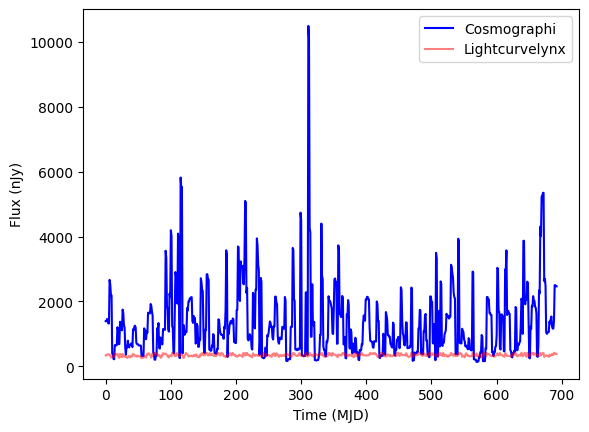

[  133.04969141   136.64989638   147.76877192   149.52572106
   157.16602435   157.62301173   158.04315662   158.39434948
   159.57973519   163.57034795   168.09472505   171.27190557
   176.21776948   178.87135531   179.13286994   184.24504633
   185.89602332   187.1950527    187.46865289   189.42023224
   191.56272014   191.84277281   198.95862747   201.42505203
   202.26546705   203.0595769    203.24851276   213.92682076
   214.90975505   215.10948308   215.40145889   215.50628348
   222.80985504   223.39195202   224.34589723   242.14071425
   243.16986508   247.42045969   250.8998175    251.57804783
   251.6279923    254.00345642   256.66211811   260.95631334
   265.15213307   270.19179599   270.47363841   273.97776732
   274.47114435   276.10028072   277.84962403   280.26986406
   280.89983496   285.92025555   286.31904212   286.54034565
   287.80853955   302.56499248   306.71495197   307.54331507
   307.75943352   311.43754921   317.36860336   317.39432843
   318.01349917   318.03

In [12]:
plt.plot(my_model_flux_comparable_units, color="blue", label="Cosmographi")
plt.plot(flux, color='red', label="Lightcurvelynx", alpha=0.5)
plt.xlabel("Time (MJD)")
plt.ylabel("Flux (nJy)")
plt.legend()
plt.show()

print(np.unique(my_model_flux_comparable_units))

In [13]:
# scale, noise = results_gp.x
# num_perturbation_samples = 1000 #TODO: different form fitting
# key = jax.random.key(1)
# perturbations2 = generate_perturbations_gp(scale=scale, noise=noise, num_samples=num_perturbation_samples, key=key)
# agn2 = AGNSourceNearestNeighbours(blackhole_mass=bh_mass, accretion_rate=accretion_rate, perturbations_ar = perturbations2, 
#                                 start_time=start_time, end_time=end_time, rin_to_rng=6, inclination_angle=0)
# rubin = RubinObservatory()
# rubin.throughput.trim()
# rubin.throughput.to_dynamic() 
# band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, filters, return_dict=True)
# key = jax.random.key(1)
# agn2.t0 = start_time
# C = cp.cosmology.Cosmology()
# agn2.z = redshift
# agn2.cosmology = C
# agn2.mu = agn2.cosmology.distance_modulus(redshift)
# source_values = jnp.asarray(agn2.get_values())
# survey_values = jnp.asarray(rubin.get_values())  
# obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
# model_flux2 = obs(key, band, exp_times, sky_brightnesses, PSF_Aeffs, agn2, times, source_values, survey_values)[2]
# model_flux_jansky2 = convert_to_jy(model_flux2, band, zero_points, rubin.effective_aperture)
# model_flux_comparable_units2 = model_flux_jansky2 * 1e9

In [14]:
# scale, noise = results_gp.x
# # scale, noise = results_gp.x[0], 150
# start_time, end_time = (times[0], times[-1])
# num_perturbation_samples = 1000 #TODO: different form fitting
# key = jax.random.key(1)
# perturbations2 = generate_perturbations_gp(scale=scale, noise=noise, num_samples=num_perturbation_samples, key=key)
# agn2 = AGNSourceLipunova2018(blackhole_mass=bh_mass, accretion_rate=accretion_rate, perturbations_ar = perturbations2, 
#                                 start_time=start_time, end_time=end_time, rin_to_rng=6, inclination_angle=0)
# rubin = RubinObservatory()
# rubin.throughput.trim()
# rubin.throughput.to_dynamic() 
# band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, filters, return_dict=True)
# agn2.t0 = start_time
# C = cp.cosmology.Cosmology()
# agn2.z = redshift
# agn2.cosmology = C
# agn2.mu = agn.cosmology.distance_modulus(redshift)
# source_values2 = jnp.asarray(agn2.get_values())
# print(source_values)
# survey_values2 = jnp.asarray(rubin.get_values())    
# print(survey_values)
# obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
# model_flux2 = obs(key, band, exp_times, sky_brightnesses, PSF_Aeffs, agn2, times, source_values2, survey_values2)[2]
# model_flux_jansky2 = convert_to_jy(model_flux2, band, zero_points, rubin.effective_aperture)
# model_flux_comparable_units2 = model_flux_jansky2 * 1e9

In [15]:
# single_flux = rubin.observe(key, band[0], exp_times[0], sky_brightnesses[0], PSF_Aeffs[0], agn2, times[0], source_values2, survey_values2)
# single_flux_jansky = convert_to_jy(single_flux[2], band[0], zero_points, rubin.effective_aperture)
# single_flux_comparable_units = single_flux_jansky * 1e9
# print(single_flux_comparable_units)
# print(agn2.perturbations.value)
# print(agn2.times[0], agn2.times[-1])
# print(times[0], times[-1])

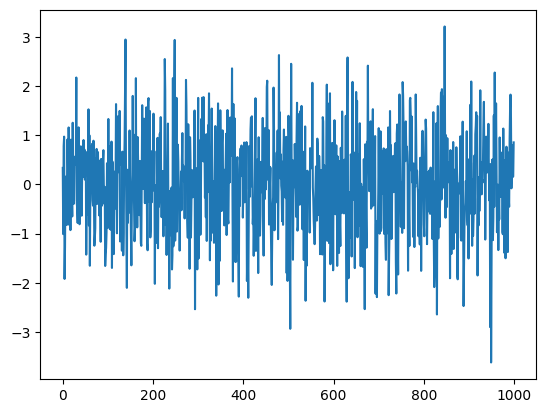

In [16]:

plt.plot(perturbations)
plt.show()


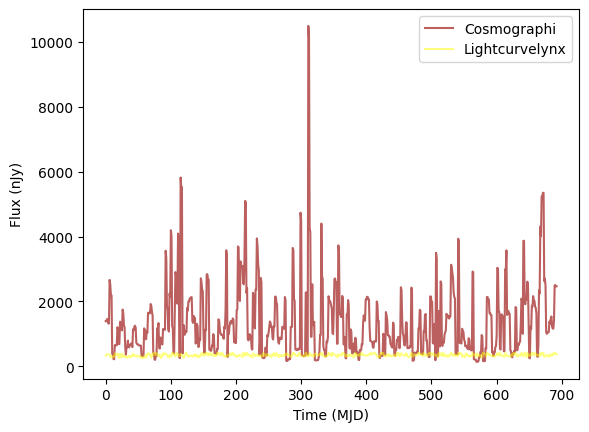

In [17]:
plt.plot(my_model_flux_comparable_units, color="brown", label="Cosmographi", alpha=0.75)
# plt.plot(model_flux_comparable_units2, color="green", label="Cosmographi - DRW", alpha=0.5)
plt.plot(flux, color='yellow', label="Lightcurvelynx", alpha=0.5)
plt.xlabel("Time (MJD)")
plt.ylabel("Flux (nJy)")
plt.legend()
plt.show()

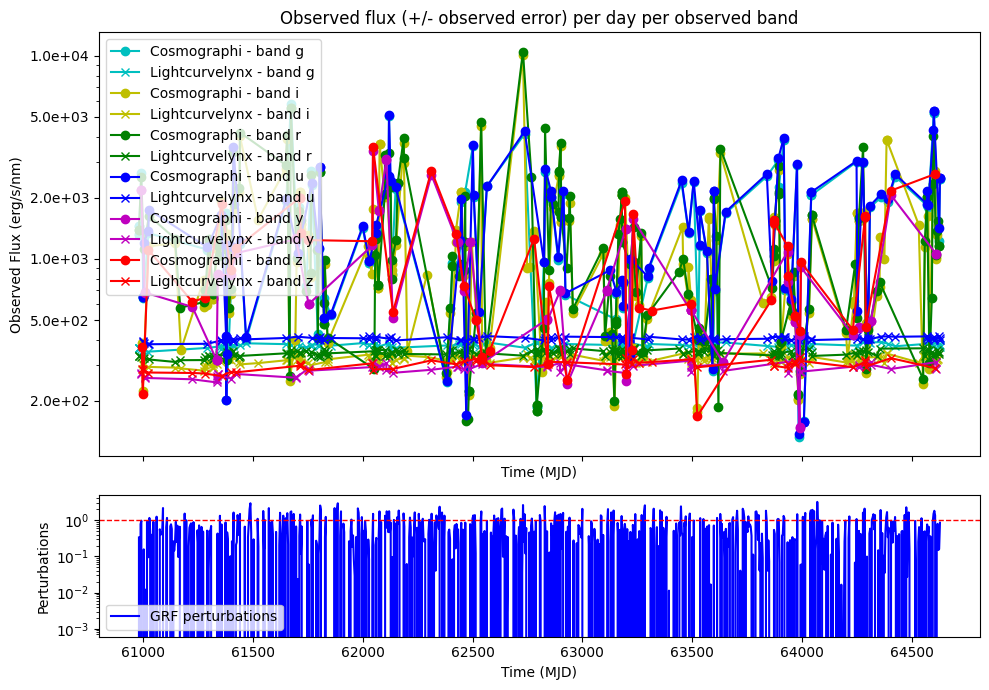

7.105427357601002e-18


In [18]:
import matplotlib.ticker as ticker
band_markers = {"u": "o", "g": "s", "r": "^", "i": "D", "z": "v", "y": "x",}
band_colors = {"u": "#0000FF", "g":"#00BFBF", "r": "#008000", "i": "#BFBF00", "z": "#FF0000", "y": "#BF00BF"}

my_model_flux_comparable_units = my_model_flux_comparable_units.flatten()


fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

band_strs= []
for i in range(len(band)):
    bandstr = idx_to_bandstr[band[i].item()]
    band_strs.append(bandstr)
band_strs = np.asarray(band_strs).reshape(-1)
for b in np.unique(band_strs):
    m = band_strs == b
    ax1.plot(
        times[m],
        my_model_flux_comparable_units[m],
        color=band_colors[b],
        marker="o",
        label=f"Cosmographi - band {b}",
    )
    ax1.plot(
            times[m],
            flux[m],
            color=band_colors[b],
            marker="x",
            label=f"Lightcurvelynx - band {b}",
        )
    # ax1.plot(
    #         times[m],
    #         model_flux_comparable_units2[m],
    #         color=band_colors[b],
    #         marker="s",
    #         label=f"Cosmographi - DRW - band {b}",
    #     )
    # ax1.plot(
    #     times_flat[m],
    #     y_true_flat[m],
    #     color="black",
    #     marker=band_markers[b],
    #     label=b,
    #     fillstyle="none",
    #     linewidth=0.25,
    # )


ax1.set_title("Observed flux (+/- observed error) per day per observed band")
ax1.set_yscale("log")
ax1.set_xlabel("Time (MJD)")
ax1.set_ylabel("Observed Flux (erg/s/nm)")
ax1.legend()
ymin, ymax = ax1.get_ylim()
ticks = np.array([
    m * 10**exp
    for exp in range(int(np.floor(np.log10(ymin))), int(np.ceil(np.log10(ymax))) + 1)
    for m in [1, 2, 5]
])
ticks = ticks[(ticks >= ymin) & (ticks <= ymax)]
ax1.yaxis.set_major_locator(ticker.FixedLocator(ticks))
ax1.yaxis.set_major_formatter(ticker.FixedFormatter([f"{t:.1e}" for t in ticks]))
ax2.set_xlim(ax1.get_xlim())
p_times = jnp.linspace(times[0], times[-1], num=len(perturbations))
# p_times2 = jnp.linspace(times[0], times[-1], num=len(perturbations2))
ax2.plot(p_times, perturbations, color = "blue", label="GRF perturbations")
# ax2.plot(p_times2, perturbations2, color = "red", label="DRW perturbations")
ax2.axhline(y=1, linestyle="--", linewidth=1, color="red")
ax2.set_yscale("log")
ax2.set_xlabel("Time (MJD)")
ax2.set_ylabel("Perturbations")
ax2.legend()
plt.tight_layout()
plt.savefig("standard_disk_lightcurve_with_perturbations.png", dpi=200)
plt.show()

print(jnp.mean(perturbations))

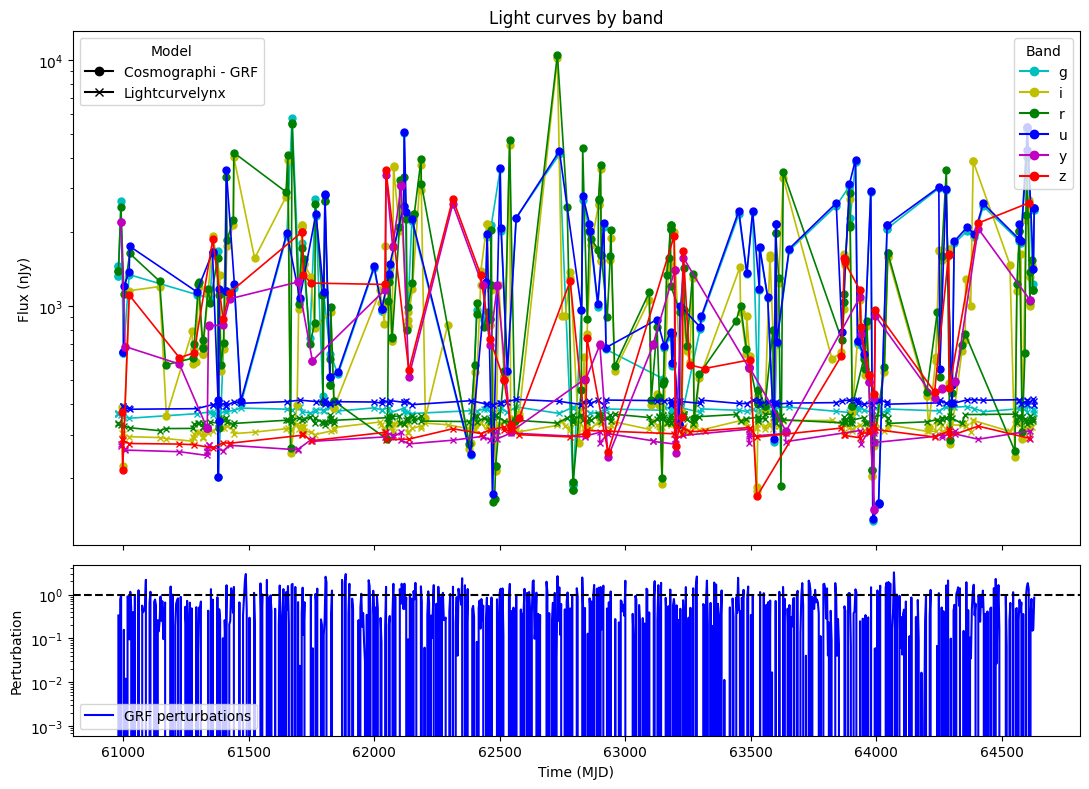

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

band_colors = {"u": "#0000FF", "g": "#00BFBF", "r": "#008000", "i": "#BFBF00", 
               "z": "#FF0000", "y": "#BF00BF"}
band_markers = {"u": "o", "g": "s", "r": "^", "i": "D", "z": "v", "y": "x"}
band_strs = np.array([idx_to_bandstr[b.item()] for b in band])
unique_bands = np.unique(band_strs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
for b in unique_bands:
    mask = band_strs == b
    ax1.plot(
        times[mask],
        my_model_flux_comparable_units[mask],
        color=band_colors[b],
        marker="o",
        linestyle="-",
        linewidth=1.2,
        markersize=5,
    )
    ax1.plot(
        times[mask],
        flux[mask],
        color=band_colors[b],
        marker="x",
        linestyle="-",
        linewidth=1.2,
        markersize=5,
    )
    # ax1.plot(
    #     times[mask],
    #     model_flux_comparable_units2[mask],
    #     color=band_colors[b],
    #     marker="s",
    #     linestyle="-",
    #     linewidth=1.2,
    #     markersize=5,
    # )

model_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        marker="o",
        linestyle="-",
        label="Cosmographi - GRF",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        marker="x",
        linestyle="-",
        label="Lightcurvelynx",
    ),
    # Line2D(
    #     [0],
    #     [0],
    #     color="black",
    #     marker="s",
    #     linestyle="-",
    #     label="Cosmographi - DRW",
    # ),
]


band_handles = [
    Line2D(
        [0],
        [0],
        color=band_colors[b],
        marker="o",
        linestyle="-",
        label=b,
    )
    for b in unique_bands
]


legend1 = ax1.legend(
    handles=model_handles,
    title="Model",
    loc="upper left",
)
legend2 = ax1.legend(
    handles=band_handles,
    title="Band",
    loc="upper right",
)
ax1.add_artist(legend1)
ax1.set_yscale("log")
ax1.set_ylabel("Flux (nJy)")
ax1.set_title("Light curves by band")

p_times = np.linspace(
    times[0],
    times[-1],
    len(perturbations)
)
# p_times2 = np.linspace(
#     times[0],
#     times[-1],
#     len(perturbations2)
# )

ax2.plot(
    p_times,
    perturbations,
    color="blue",
    label="GRF perturbations",
)
# ax2.plot(
#     p_times2,
#     perturbations2,
#     color="red",
#     label="DRW perturbations",
# )
ax2.axhline(
    1,
    linestyle="--",
    color="black",
)
ax2.set_yscale("log")
ax2.set_xlabel("Time (MJD)")
ax2.set_ylabel("Perturbation")
ax2.legend()

plt.tight_layout()
plt.show()



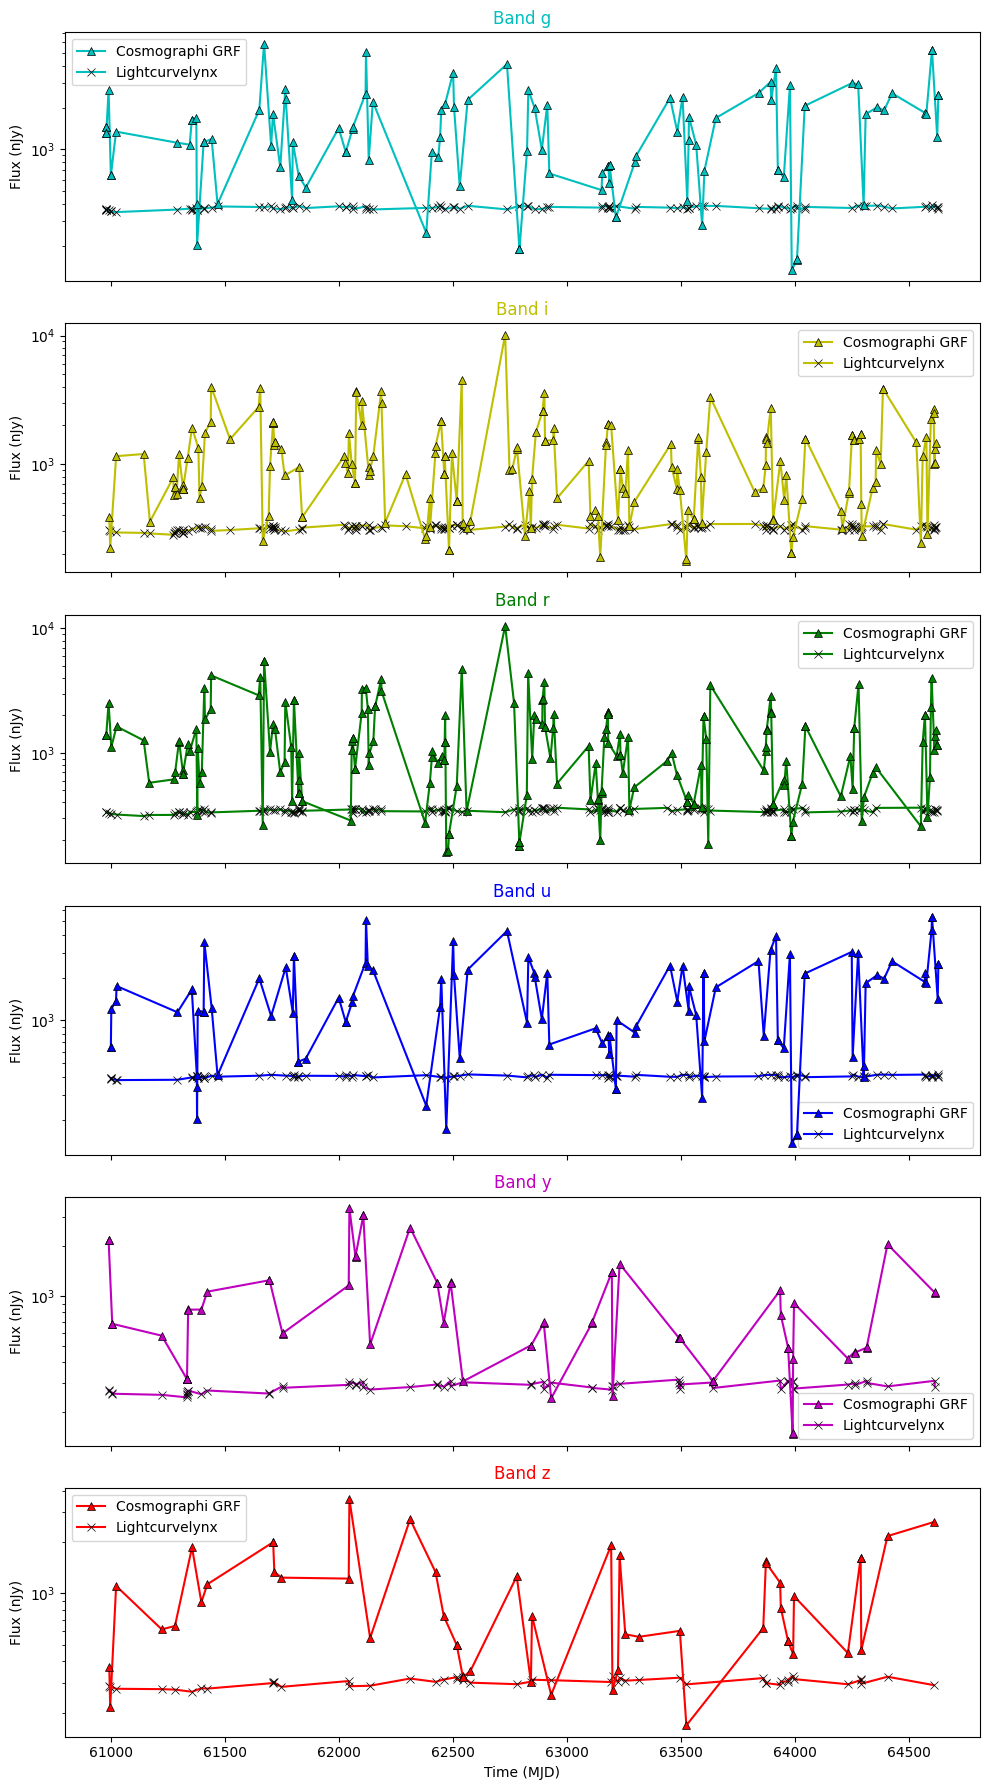

In [20]:
fig, axes = plt.subplots(len(unique_bands), 1, figsize=(10, 3 * len(unique_bands)), sharex=True)
if len(unique_bands) == 1:
    axes = [axes]
for ax, b in zip(axes, unique_bands):
    mask = band_strs == b
    ax.plot(
        times[mask],
        my_model_flux_comparable_units[mask],
        color=band_colors[b],
        marker="^",
        linestyle="-",
        label="Cosmographi GRF",
        zorder=1000,
        markeredgecolor="black",
        markeredgewidth=0.5,
    )
    ax.plot(
        times[mask],
        flux[mask],
        color=band_colors[b],
        marker="x",
        linestyle="-",
        label="Lightcurvelynx",
        markeredgecolor="black",
        markeredgewidth=0.5,
    )
    # ax.plot(
    #     times[mask],
    #     model_flux_comparable_units2[mask],
    #     color=band_colors[b],
    #     marker="s",
    #     linestyle="-",
    #     label="Cosmographi DRW",
    #     markeredgecolor="black",
    #     markeredgewidth=0.5,
    # )
    ax.set_yscale("log")
    ax.set_ylabel("Flux (nJy)")
    ax.set_title(f"Band {b}", color=band_colors[b])
    ax.legend()
axes[-1].set_xlabel("Time (MJD)")
plt.tight_layout()
plt.show()

NameError: name 'model_flux_comparable_units2' is not defined

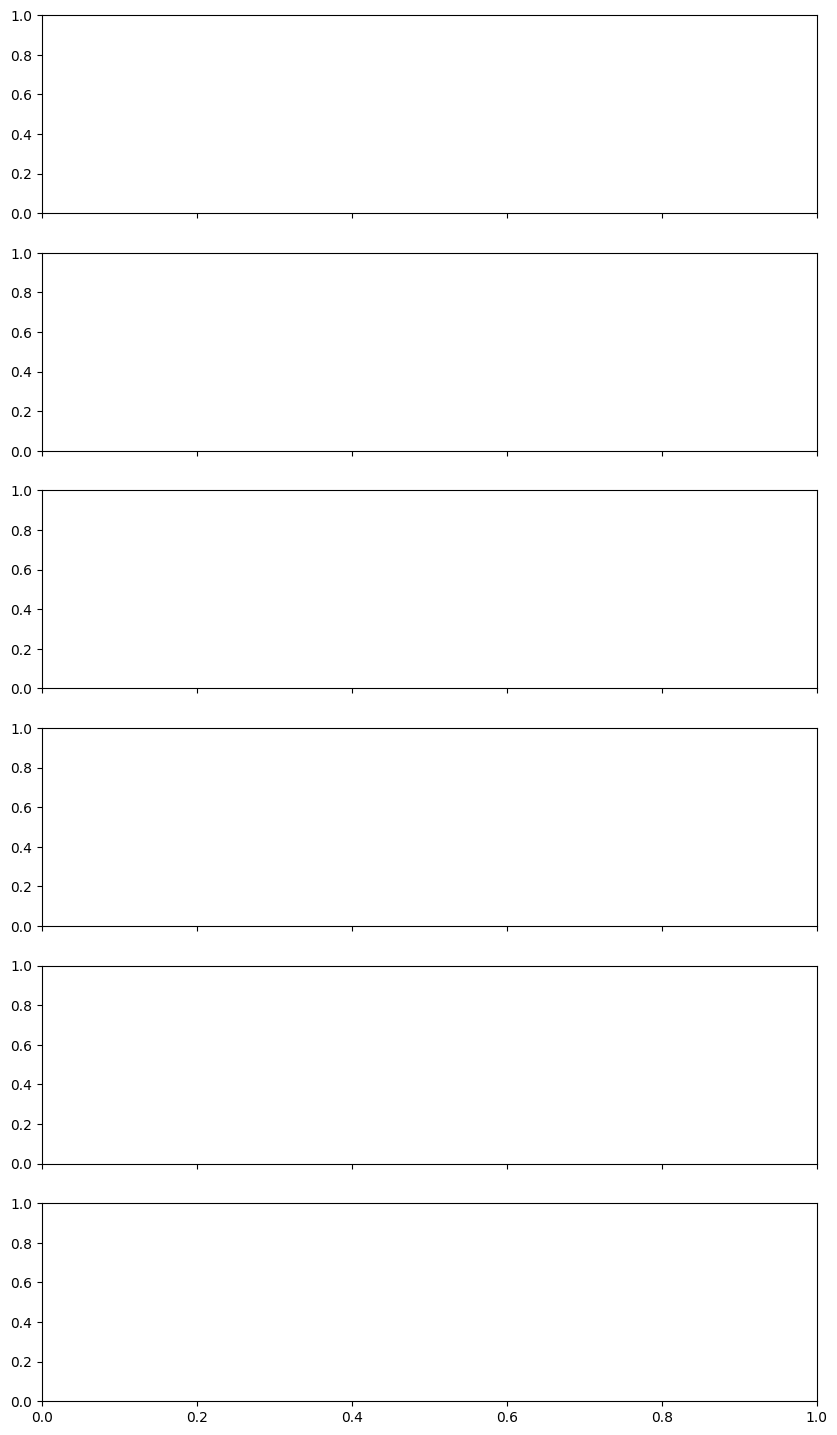

In [21]:
fig, axes = plt.subplots(len(unique_bands), 1, figsize=(10, 3 * len(unique_bands)), sharex=True)
if len(unique_bands) == 1:
    axes = [axes]
for ax, b in zip(axes, unique_bands):
    ax.plot(
        times[mask],
        model_flux_comparable_units2[mask],
        color=band_colors[b],
        marker="s",
        linestyle="-",
        label="Cosmographi DRW",
        markeredgecolor="black",
        markeredgewidth=0.5,
    )
    ax.set_ylabel("Flux (nJy)")
    ax.set_title(f"Band {b}", color=band_colors[b])
    ax.legend()
axes[-1].set_xlabel("Time (MJD)")
plt.tight_layout()
plt.show()

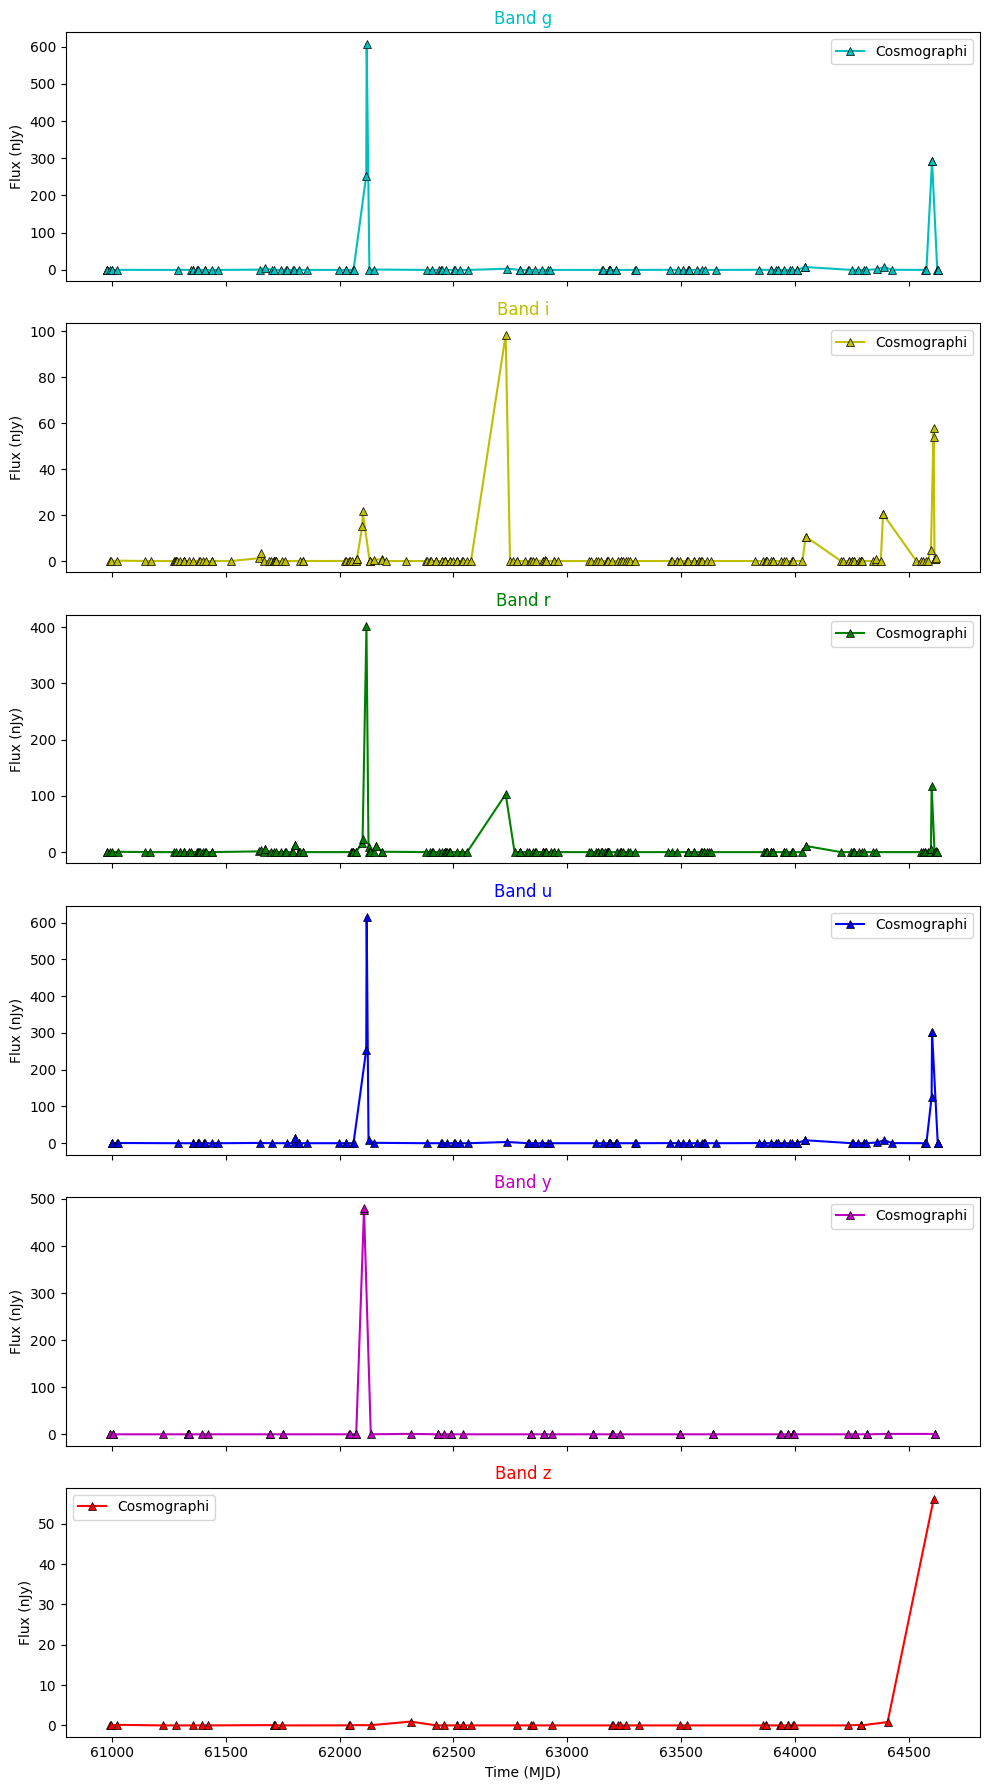

In [ ]:
fig, axes = plt.subplots(len(unique_bands), 1, figsize=(10, 3 * len(unique_bands)), sharex=True)
if len(unique_bands) == 1:
    axes = [axes]
for ax, b in zip(axes, unique_bands):
    mask = band_strs == b
    ax.plot(
        times[mask],
        my_model_flux_comparable_units[mask],
        color=band_colors[b],
        marker="^",
        linestyle="-",
        label="Cosmographi",
        markeredgecolor="black",
        markeredgewidth=0.5,
    )
    ax.set_ylabel("Flux (nJy)")
    ax.set_title(f"Band {b}", color=band_colors[b])
    ax.legend()
axes[-1].set_xlabel("Time (MJD)")
plt.tight_layout()
plt.show()



[298.69617945 316.578757   328.86627814 346.28213787 365.98275004
 373.23391246]
[1.94324552e-09 2.04776712e-09 2.18998992e-09 7.03034513e-09
 1.00961846e-08 1.05837669e-08 1.22629688e-08 1.62674165e-08
 1.66806220e-08 1.70463262e-08 1.71143688e-08 2.03222073e-08
 2.18838383e-08 2.28901934e-08 2.34231269e-08 5.47779050e-08
 7.66644221e-08 7.66821965e-08 7.71095717e-08 7.71273764e-08
 7.87288096e-08 7.88069121e-08 8.23547617e-08 8.31275625e-08
 1.38722320e-07 1.38949946e-07 1.47387191e-07 1.47626591e-07
 1.54688946e-07 1.57214875e-07 1.69114666e-07 1.83640442e-07
 2.47010230e-07 2.57845605e-07 2.62513628e-07 2.63697239e-07
 2.69016086e-07 2.70266651e-07 3.05065893e-07 3.18048812e-07
 3.19232351e-07 3.50937082e-07 3.51150819e-07 3.66182345e-07
 3.92998320e-07 3.93107801e-07 4.13433981e-07 4.13549139e-07
 4.94123419e-07 5.60106233e-07 5.64775957e-07 5.74457249e-07
 5.76713525e-07 5.81953203e-07 5.86870770e-07 6.03675132e-07
 6.04114748e-07 6.47065168e-07 6.48641958e-07 6.90148530e-07
 6.9

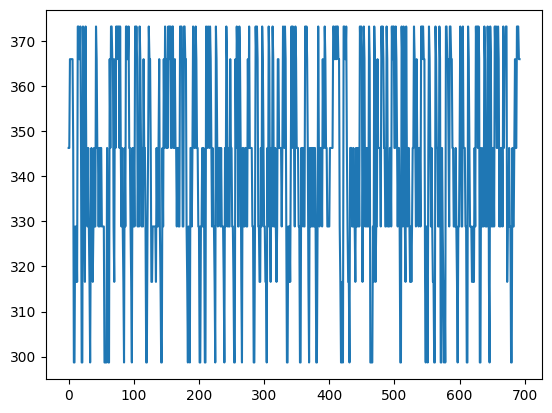

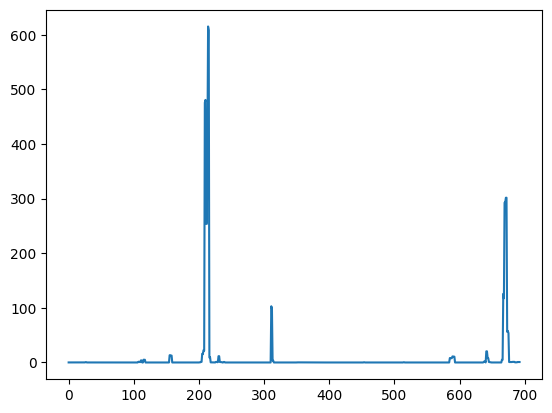

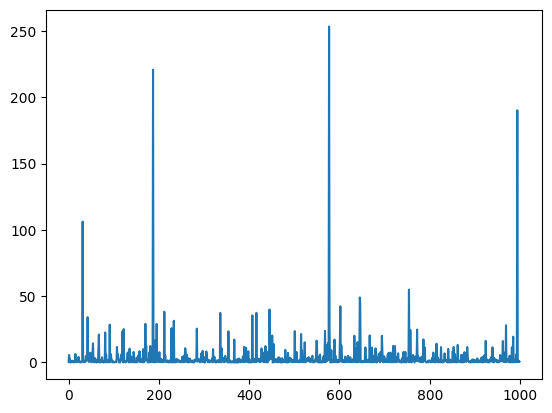

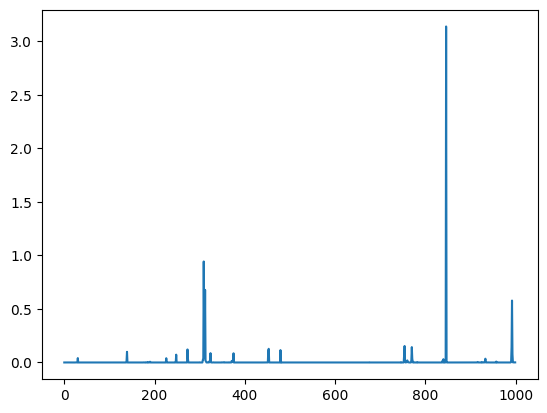

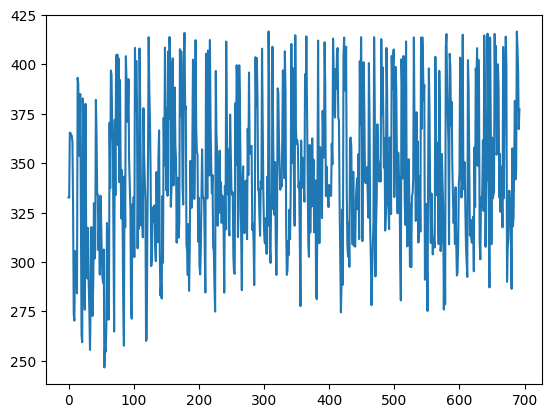

346.2821378749257
0.07693549254539772
1000
[7.74397482e-05 1.34573562e-06 9.99284461e-05 5.99592476e-05
 7.95117903e-09 2.42871947e-08 2.08488470e-06 1.61696247e-06
 3.89286835e-06 1.24793163e-06 2.68184201e-04 4.87709893e-04
 1.00220480e-04 1.33852051e-03 1.15215035e-04 1.93998601e-06
 2.01051563e-05 1.22423257e-06 1.20648954e-04 1.59201319e-05
 5.99736166e-06 3.14078779e-06 4.65386383e-04 1.59642507e-05
 4.37278091e-06 9.14045053e-06 1.70070458e-04 2.40410228e-04
 3.52283125e-04 8.64178318e-04 4.07487969e-02 2.29605518e-05
 3.22786842e-06 1.78629561e-06 1.32742513e-04 6.12204251e-04
 1.02381109e-05 5.67189695e-07 8.19682844e-07 8.99957503e-05
 2.45343575e-04 8.77604527e-05 2.83989484e-06 2.38888541e-05
 2.78719538e-05 5.30743314e-05 3.21362314e-04 6.17063765e-05
 1.11841022e-04 1.43580712e-05 1.37966645e-05 8.84801340e-06
 1.61439582e-08 1.23823042e-07 1.07280445e-07 7.68963150e-08
 5.94585844e-07 5.87837131e-05 1.98613008e-07 4.95589429e-06
 5.56774646e-09 1.45897794e-07 2.01185363e

In [ ]:



print(jnp.unique(model_flux_comparable_units2))
print(jnp.unique(my_model_flux_comparable_units))
single_flux = rubin.observe(key, band[15], exp_times[15], sky_brightnesses[15], PSF_Aeffs[15], agn2, times[15], source_values2, survey_values2)
single_flux_jansky = convert_to_jy(single_flux[2], band[15], zero_points, rubin.effective_aperture)
single_flux_comparable_units = single_flux_jansky * 1e9
print(single_flux_comparable_units)


single_flux = rubin.flux(band[15], agn2, times[15], source_values2, survey_values2)
single_flux_jansky = convert_to_jy(single_flux[2], band[15], zero_points, rubin.effective_aperture)
single_flux_comparable_units = single_flux_jansky * 1e9
print(single_flux_comparable_units)
print(agn2.base_luminosity_density(w=jnp.asarray([900])))

print("luminosity density drw:")
print(agn2.luminosity_density(w=jnp.asarray([900]), t=times[0]))
print(agn2.luminosity_density(w=jnp.asarray([900]), t=61500))
print(agn2.luminosity_density(w=jnp.asarray([900]), t=62000))
print(agn2.luminosity_density(w=jnp.asarray([900]), t=times[500]))
print(agn2.luminosity_density(w=jnp.asarray([900]), t=64000))
print(agn2.luminosity_density(w=jnp.asarray([900]), t=times[-1]))

print("luminosity density:") # in rest frame
print(agn.luminosity_density(w=jnp.asarray([900]), t=times[0]))
print(agn.luminosity_density(w=jnp.asarray([900]), t=61500))
print(agn.luminosity_density(w=jnp.asarray([900]), t=62000))
print(agn.luminosity_density(w=jnp.asarray([900]), t=times[500]))
print(agn.luminosity_density(w=jnp.asarray([900]), t=64000))
print(agn.luminosity_density(w=jnp.asarray([900]), t=times[-1]))
# check agn.perturbations range is within agn.times after observer-rest frame time transformations

print("spectral_flux_density:") # in observer frame
print(agn.spectral_flux_density(w=jnp.asarray([900]), t=times[0], z=agn.z.value, mu=agn.mu.value))
print(agn.spectral_flux_density(w=jnp.asarray([900]), t=61500, z=agn.z.value, mu=agn.mu.value))
print(agn.spectral_flux_density(w=jnp.asarray([900]), t=62000, z=agn.z.value, mu=agn.mu.value))
print(agn.spectral_flux_density(w=jnp.asarray([900]), t=times[500], z=agn.z.value, mu=agn.mu.value))
print(agn.spectral_flux_density(w=jnp.asarray([900]), t=64000, z=agn.z.value, mu=agn.mu.value))
print(agn.spectral_flux_density(w=jnp.asarray([900]), t=times[-1], z=agn.z.value, mu=agn.mu.value))


# print("spectral_flux_density:")
# print(agn.spectral_flux_density(w=band[0], t=times[0], z=agn.z.value, mu=agn.mu.value))
# print(agn.spectral_flux_density(w=band[0], t=61500, z=agn.z.value, mu=agn.mu.value))
# # print(agn.spectral_flux_density(w=jnp.asarray([900]), t=62000, z=agn.z.value, mu=agn.mu.value))
# # print(agn.spectral_flux_density(w=jnp.asarray([900]), t=times[500], z=agn.z.value, mu=agn.mu.value))
# # print(agn.spectral_flux_density(w=jnp.asarray([900]), t=64000, z=agn.z.value, mu=agn.mu.value))
# print(agn.spectral_flux_density(w=band[0], t=times[-1], z=agn.z.value, mu=agn.mu.value))


print("single flux:")
print(len(agn2.perturbations.value))
print(rubin.flux(band[0], agn2, times[0], source_values2, survey_values2))
print(rubin.flux(band[0], agn2, times[50], source_values2, survey_values2))
print(rubin.flux(band[0], agn2, times[100], source_values2, survey_values2))
print(rubin.flux(band[0], agn2, times[500], source_values2, survey_values2))
print(rubin.flux(band[0], agn2, times[-12], source_values2, survey_values2))
print(rubin.flux(band[0], agn2, times[-4], source_values2, survey_values2))
print(rubin.flux(band[0], agn2, times[-3], source_values2, survey_values2))
print(rubin.flux(band[0], agn2, times[-2], source_values2, survey_values2))
print(rubin.flux(band[0], agn2, times[-1], source_values2, survey_values2))

print(np.shape(band), np.shape(times))

plt.plot(model_flux_comparable_units2)
plt.show()

plt.plot(my_model_flux_comparable_units)
plt.show()

plt.plot(perturbations2)
plt.show()

plt.plot(perturbations)
plt.show()

plt.plot(flux)
plt.show()

print(model_flux_comparable_units2[0])
print(my_model_flux_comparable_units[0])

print(len(perturbations))
print(agn.perturbations.value)
print(jnp.mean(perturbations))
# print(agn2.perturbations.value)

#4.30018177e-27

In [ ]:
# perturbations = jnp.asarray([0, 100, 50, 0.1, 0.01])
test_times = jnp.asarray([10, 20, 30, 40, 50])
test_times2 = jnp.asarray([15, 25, 35, 45, 55])
w=jnp.asarray([900])
agn3 = AGNSourceLipunova2018(blackhole_mass = M_sun*1e8, accretion_rate=M_sun *0.5, inclination_angle=0, start_time=test_times[0], end_time=test_times[-1], perturbations_ar=perturbations)
print(agn3.luminosity_density(w=w, t=test_times))
print(agn3.luminosity_density(w=w, t=test_times2))
print(agn3.base_luminosity_density(w=w))



[[4.86322764e+36]
 [1.08598466e+35]
 [4.14316118e+34]
 [8.92853537e+34]
 [4.94834345e+37]]
[[1.10618843e+36]
 [3.43236410e+39]
 [4.17251384e+33]
 [1.36906865e+29]
 [4.94834345e+37]]
[6.28001478e+40]
